# 台指期日盤當沖

這份 notebook 只使用日盤價格回測。夜盤 OHLC 等 `_a` 欄位會被忽略，但保留 `Foreign_Opt_Signal_a` 作為日盤交易訊號因子。

In [27]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from pathlib import Path
import sys

import pandas as pd


def find_strategy_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    fallback = Path(r"D:/Github/Personal-Project/ndhu/portfolio_management") / "台指期當沖"
    candidates.append(fallback)
    for candidate in candidates:
        if (candidate / "tx_daytrade.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Cannot locate tx_daytrade.py.")


ROOT = find_strategy_root()
GITHUB_ROOT = next((p for p in [ROOT, *ROOT.parents] if p.name.lower() == "github"), ROOT.parents[3])
NOTE_ROOT = GITHUB_ROOT / "note"
QUANT_TX_ROOT = GITHUB_ROOT / "Quant" / "projects" / "workStrategy" / "TX"
AGGREGATE_RESULTS = ROOT.parent / "aggregate" / "results" / "tx_daytrade"
AGGREGATE_RESULTS_WRONG = ROOT.parent / "aggregate" / "results" / "tx_daytrade_wrong"

for path in [ROOT, NOTE_ROOT]:
    if path.exists() and str(path) not in sys.path:
        sys.path.append(str(path))

from tx_daytrade import TXDayTradeStrategy, save_tx_strategy_result
from tx_feature_capture import capture_tx_day_features

ROOT, NOTE_ROOT, QUANT_TX_ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/台指期當沖'),
 WindowsPath('D:/Github/note'),
 WindowsPath('D:/Github/Quant/projects/workStrategy/TX'))

## 資料

`tx_features` 需要包含日盤 OHLC、SOX、MOVE 和夜盤外資選擇權訊號 `Foreign_Opt_Signal_a`。載入後會移除其他 `_a` 夜盤欄位，只保留這個訊號因子。

In [29]:
START = "2020-01-01"
END = datetime(2026, 5, 26)
RECAPTURE_DATA = False
PRICE_MODE = "legacy_next_session"
FACTOR_MODE = "legacy"
ADDITIVE_EQUITY = True
FEATURE_CACHE = ROOT / "data" / "tx_features.parquet"
SOURCE_BACKTEST = QUANT_TX_ROOT / "backtest.csv"

FEATURE_CACHE.parent.mkdir(parents=True, exist_ok=True)

if RECAPTURE_DATA:
    DATA_SOURCE = "recaptured"
    tx_features = capture_tx_day_features(
        start=START,
        end=END,
        note_root=NOTE_ROOT,
        output_path=FEATURE_CACHE,
    )
elif FEATURE_CACHE.exists():
    DATA_SOURCE = str(FEATURE_CACHE)
    tx_features = pd.read_parquet(FEATURE_CACHE)
elif SOURCE_BACKTEST.exists():
    DATA_SOURCE = str(SOURCE_BACKTEST)
    tx_features = pd.read_csv(SOURCE_BACKTEST, index_col=0, parse_dates=True)
    tx_features.index.name = "Timestamp"
else:
    raise FileNotFoundError(
        "No tx_features cache or source backtest.csv found. "
        "Set RECAPTURE_DATA = False to download fresh features."
    )

if not isinstance(tx_features.index, pd.DatetimeIndex):
    tx_features.index = pd.to_datetime(tx_features.index)

START_TS = pd.Timestamp(START)
END_TS = pd.Timestamp(END)
tx_features = tx_features.loc[(tx_features.index >= START_TS) & (tx_features.index <= END_TS)].copy()

if tx_features.empty:
    raise ValueError(f"No tx_features data between {START_TS.date()} and {END_TS.date()}.")

if "trading_session" in tx_features.columns:
    tx_features = tx_features[tx_features["trading_session"] == "position"].copy()

keep_a_columns = {"Foreign_Opt_Signal_a"}
if PRICE_MODE == "legacy_next_session":
    keep_a_columns.update({"Open_a", "Close_a", "High_a", "Low_a", "trading_session_a", "futures_id_a"})
a_columns = [
    col for col in tx_features.columns
    if col.endswith("_a") and col not in keep_a_columns
]
if a_columns:
    tx_features = tx_features.drop(columns=a_columns)

if PRICE_MODE == "legacy_next_session":
    missing_legacy_cols = sorted({"Open_a", "Close_a"} - set(tx_features.columns))
    if missing_legacy_cols:
        raise ValueError(
            f"PRICE_MODE={PRICE_MODE} requires {missing_legacy_cols}. "
            "Set RECAPTURE_DATA = False to rebuild tx_features with night-session prices."
        )

tx_features = tx_features.sort_index()
tx_features.to_parquet(FEATURE_CACHE)

actual_start = tx_features.index.min()
actual_end = tx_features.index.max()
print(f"source={DATA_SOURCE}")
print(f"requested={START_TS.date()} to {END_TS.date()}")
print(f"actual rows={len(tx_features):,}, columns={len(tx_features.columns):,}, range={actual_start.date()} to {actual_end.date()}")
if actual_start > START_TS:
    print(f"WARNING: data starts at {actual_start.date()}, later than requested {START_TS.date()}.")
tx_features.head()


source=D:\Github\Personal-Project\ndhu\portfolio_management\台指期當沖\data\tx_features.parquet
requested=2020-01-01 to 2026-05-26
actual rows=1,551, columns=28, range=2020-01-02 to 2026-05-26


,futures_id,contract_date,monthly_group,Open,High,Low,Close,spread,spread_per,Volume,...,trading_session_a,Foreign_Opt_Signal_a,MOVE_open,MOVE_high,MOVE_low,MOVE_close,SOX_open,SOX_high,SOX_low,SOX_close
Timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-02,TX,202001,2020-01-15,12044.0,12120.0,12023.0,12102.0,108.0,0.90,100401.0,...,after_market,NaN,58.2812,58.2812,58.2812,58.2812,1836.18,1851.06,1835.29,1849.62
2020-01-03,TX,202001,2020-01-15,12180.0,12198.0,11996.0,12086.0,-15.0,-0.12,172660.0,...,after_market,NaN,57.2043,57.2043,57.2043,57.2043,1875.34,1888.14,1864.93,1887.91
2020-01-06,TX,202001,2020-01-15,12017.0,12034.0,11948.0,11950.0,-137.0,-1.13,118380.0,...,after_market,NaN,60.1223,60.1223,60.1223,60.1223,1850.82,1869.72,1848.65,1853.98
2020-01-07,TX,202001,2020-01-15,11995.0,12009.0,11816.0,11871.0,-78.0,-0.65,157264.0,...,after_market,NaN,62.7943,62.7943,62.7943,62.7943,1825.59,1840.19,1821.86,1834.68
2020-01-08,TX,202001,2020-01-15,11728.0,11892.0,11697.0,11788.0,-83.0,-0.70,158971.0,...,after_market,NaN,62.6250,62.6250,62.6250,62.6250,1852.73,1875.61,1845.50,1867.28


In [30]:
required_factor_columns = {
    "SOX_open",
    "SOX_close",
    "MOVE_open",
    "MOVE_high",
    "MOVE_low",
    "MOVE_close",
    "Foreign_Opt_Signal_a",
}
missing = sorted(required_factor_columns - set(tx_features.columns))

if missing:
    raise ValueError(
        "tx_features is missing required strategy factor columns. "
        f"Missing columns: {missing}. Provide data/tx_features.parquet or Quant/projects/workStrategy/TX/backtest.csv."
    )

## 回測

In [31]:
POINT_VERSION = False

strategy = TXDayTradeStrategy(tx_features)
result = strategy.backtest(
    point_version=POINT_VERSION,
    price_mode=PRICE_MODE,
    factor_mode=FACTOR_MODE,
    additive_equity=ADDITIVE_EQUITY,
)

summary = result["summary_table"]
portfolio = result["portfolio"]
backtest = result["backtest"]

display(summary)
portfolio.tail()

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,trades,win_rate,profit_factor,avg_return,price_mode,factor_mode,equity_mode
Strategy,0.791990,0.128679,0.119302,1.078604,-0.200755,1066.0,0.541276,1.262392,0.000743,legacy_next_session,legacy,additive
BuyHold,1.437727,0.233596,0.219360,1.064896,-0.365525,1545.0,0.554693,1.214995,0.000931,legacy_next_session,legacy,additive


,strategy_return,benchmark_return,equity_curve,drawdown,benchmark_equity_curve,benchmark_drawdown,pos_day
Timestamp,,,,,,,
2026-05-20,0.000000,-0.004224,0.762798,-0.080163,1.345379,-0.054604,0.0
2026-05-21,0.008446,0.034807,0.771244,-0.071718,1.380186,-0.019797,1.0
2026-05-22,0.005119,0.023365,0.776363,-0.066599,1.403551,0.000000,1.0
2026-05-25,0.015627,0.033811,0.791990,-0.050972,1.437362,0.000000,1.0
2026-05-26,0.000000,0.000365,0.791990,-0.050972,1.437727,0.000000,1.0


Text(0, 0.5, 'Additive Return')

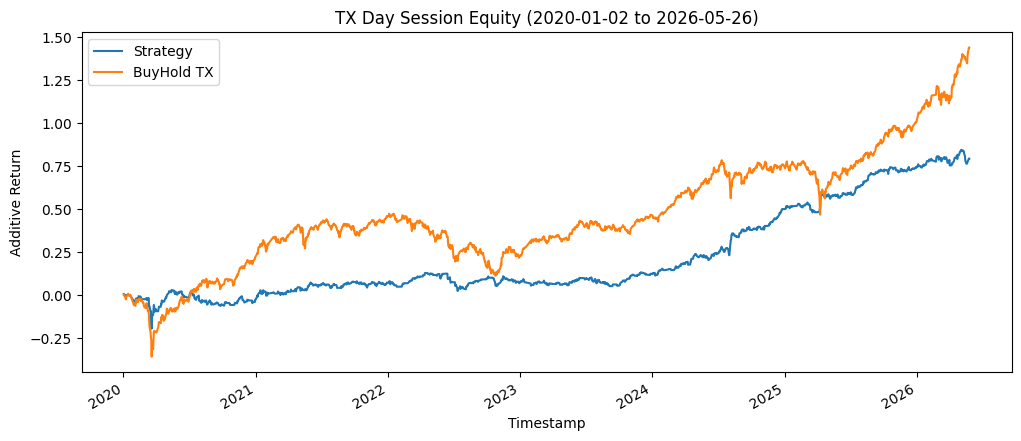

In [32]:
plot_df = portfolio[["equity_curve", "benchmark_equity_curve"]].rename(
    columns={
        "equity_curve": "Strategy",
        "benchmark_equity_curve": "BuyHold TX",
    }
)
ax = plot_df.plot(
    figsize=(12, 5),
    title=f"TX Day Session Equity ({portfolio.index.min().date()} to {portfolio.index.max().date()})",
)
ax.set_ylabel("Additive Return" if ADDITIVE_EQUITY else "Equity")


## 輸出給組合彙整

In [33]:
paths = save_tx_strategy_result(
    result,
    output_dir=AGGREGATE_RESULTS,
    config={
        "strategy_name": "tx_daytrade_day_session",
        "source": str(ROOT),
        "feature_cache": str(FEATURE_CACHE),
        "start": str(pd.Timestamp(START).date()),
        "end": str(pd.Timestamp(END).date()),
        "point_version": POINT_VERSION,
        "price_mode": PRICE_MODE,
        "factor_mode": FACTOR_MODE,
        "equity_mode": "additive" if ADDITIVE_EQUITY else "compound",
        "session": "day",
    },
)

paths

{'portfolio': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/tx_daytrade/portfolio.parquet'),
 'backtest': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/tx_daytrade/backtest.parquet'),
 'summary': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/tx_daytrade/summary.csv'),
 'config': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/tx_daytrade/config.json'),
 'manifest': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/tx_daytrade/manifest.json')}

## 錯誤純日盤策略回測

這個區塊保留前面誤改過的純日盤邏輯，用來和目前 legacy 策略比較。它使用 `Close / Open - 1` 當交易報酬，並用日盤 `Close` 計算乖離與 `Open / Close.shift(1) - 1` 計算 gap。

In [25]:
WRONG_PRICE_MODE = "day_open_close"
WRONG_FACTOR_MODE = "pure_day"
WRONG_ADDITIVE_EQUITY = False

wrong_result = strategy.backtest(
    point_version=POINT_VERSION,
    price_mode=WRONG_PRICE_MODE,
    factor_mode=WRONG_FACTOR_MODE,
    additive_equity=WRONG_ADDITIVE_EQUITY,
)

wrong_summary = wrong_result["summary_table"]
wrong_portfolio = wrong_result["portfolio"]
wrong_backtest = wrong_result["backtest"]

print(f"wrong backtest range={wrong_backtest.index.min().date()} to {wrong_backtest.index.max().date()}, rows={len(wrong_backtest):,}")
display(wrong_summary)
wrong_portfolio.tail()


wrong backtest range=2020-01-02 to 2026-05-26, rows=1,551


,total_return,annual_return,annual_volatility,sharpe,max_drawdown,trades,win_rate,profit_factor,avg_return,price_mode,factor_mode,equity_mode
Strategy,4.130646,0.304325,0.109847,2.770436,-0.102005,1070.0,0.58972,1.698458,0.001564,day_open_close,pure_day,compound


,strategy_return,equity_curve,drawdown,pos_day
Timestamp,,,,
2026-05-20,0.000000,5.003412,-0.065608,0.0
2026-05-21,0.012351,5.065211,-0.054067,1.0
2026-05-22,0.005830,5.094741,-0.048552,1.0
2026-05-25,0.015789,5.175181,-0.033530,1.0
2026-05-26,-0.008606,5.130646,-0.041847,1.0


Text(0, 0.5, 'Equity')

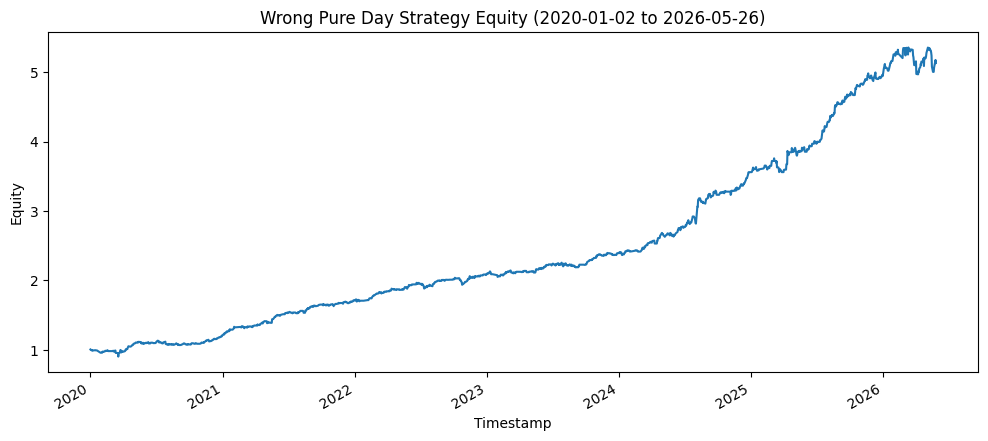

In [26]:
wrong_plot_df = wrong_portfolio[["equity_curve", "benchmark_equity_curve"]].rename(
    columns={
        "equity_curve": "Wrong Strategy",
        "benchmark_equity_curve": "BuyHold TX",
    }
)
ax = wrong_plot_df.plot(
    figsize=(12, 5),
    title=f"Wrong Pure Day Strategy Equity ({wrong_portfolio.index.min().date()} to {wrong_portfolio.index.max().date()})",
)
ax.set_ylabel("Additive Return" if WRONG_ADDITIVE_EQUITY else "Equity")


In [ ]:
wrong_paths = save_tx_strategy_result(
    wrong_result,
    output_dir=AGGREGATE_RESULTS_WRONG,
    config={
        "strategy_name": "tx_daytrade_wrong_pure_day",
        "source": str(ROOT),
        "feature_cache": str(FEATURE_CACHE),
        "start": str(pd.Timestamp(START).date()),
        "end": str(pd.Timestamp(END).date()),
        "point_version": POINT_VERSION,
        "price_mode": WRONG_PRICE_MODE,
        "factor_mode": WRONG_FACTOR_MODE,
        "equity_mode": "additive" if WRONG_ADDITIVE_EQUITY else "compound",
        "session": "day",
        "note": "Intentional reproduction of the earlier incorrect pure-day strategy logic.",
    },
)

wrong_paths

## 回測邏輯比較

### 剛才錯誤的純日盤版本

這版把「只要日盤」理解成只保留日盤價格，所以把多數 `_a` 欄位刪掉，只留下 `Foreign_Opt_Signal_a`。因此價格、乖離和 gap 都改成用日盤資料計算：

```python
day_return = Close / Open - 1
strategy_return = day_return * pos_day
benchmark_return = day_return

3_ma = Close.rolling(3).mean()
divergence = Close / 3_ma - 1
gap = Open / Close.shift(1) - 1
```

績效曲線也曾用複利 equity curve：

```python
equity_curve = (1 + strategy_return).cumprod()
```

這和原本策略不一致，因為原策略雖然交易的是日盤方向，但訊號和報酬定義有用到夜盤價格欄位。

### 目前修正後的 legacy 版本

目前版本保留日盤交易方向，但恢復原本 analyzer 的價格定義。也就是保留 `Open_a`、`Close_a` 和 `Foreign_Opt_Signal_a`，用夜盤資訊決定隔日日盤交易：

```python
day_return = Open_a.shift(-1) / Open - 1
strategy_return = day_return * pos_day
benchmark_return = day_return

3_ma = Close_a.rolling(3).mean()
divergence = Close_a / 3_ma - 1
gap = Close_a / Close.shift(1) - 1
```

績效曲線改回和舊圖一致的累加報酬：

```python
equity_curve = strategy_return.cumsum()
```

### 核心差異

| 項目 | 錯誤純日盤版 | 目前 legacy 版 |
|---|---|---|
| 交易報酬 | `Close / Open - 1` | `Open_a.shift(-1) / Open - 1` |
| Benchmark | 日盤 `Open -> Close` | 同策略交易區間的 `day_return` |
| 乖離 | `Close` 的 3 日均線 | `Close_a` 的 3 日均線 |
| Gap | `Open / Close.shift(1) - 1` | `Close_a / Close.shift(1) - 1` |
| 外資選擇權因子 | `Foreign_Opt_Signal_a` | `Foreign_Opt_Signal_a` |
| `_a` 欄位 | 幾乎全部刪掉 | 保留 `Open_a`、`Close_a`、`Foreign_Opt_Signal_a` |
| 績效曲線 | 曾用複利 `cumprod` | 改回累加 `cumsum` |

目前仍和舊圖不完全一致的主要原因不是公式，而是資料：目前重抓到的 `Foreign_Opt_Signal_a` 最早只有 `2023-06-05`，舊圖那份資料看起來在更早期間就有夜盤外資選擇權訊號。
